# Introduction to TensorFlow & Keras — Part 2
### The Functional API, branching models, and multi-input problems

Picking up right where Part 1 left off. There, you built and trained
`digit_classifier` — a single-input, single-output stack — using the
Sequential API, and were asked to imagine a case where Sequential
wouldn't be enough. This notebook builds that case for real.

### Code rules for this notebook
1. Keep all your imports in the next cell.
2. Give variables names that say what they hold.
3. Add type hints to every function you write.
4. Every model must go through `train_and_evaluate()` once you've written it below.

In [1]:
!pip install tensorflow

In [2]:
import numpy as np
import matplotlib.pyplot as plt
from typing import Any, Dict

import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers

RANDOM_SEED = 42
tf.random.set_seed(RANDOM_SEED)
np.random.seed(RANDOM_SEED)

(X_train_raw, y_train), (X_test_raw, y_test) = keras.datasets.mnist.load_data()
X_train = X_train_raw.reshape(-1, 28 * 28).astype("float32") / 255.0
X_test = X_test_raw.reshape(-1, 28 * 28).astype("float32") / 255.0

print(f"X_train shape: {X_train.shape}")

I0000 00:00:1789653625.472398  143738 port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
I0000 00:00:1789653625.476995  143738 cudart_stub.cc:31] Could not find cuda drivers on your machine, GPU will not be used.
I0000 00:00:1789653625.987990  143738 cpu_feature_guard.cc:227] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 AVX_VNNI FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.
I0000 00:00:1789653638.238793  143738 port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
I0000 00:0

X_train shape: (60000, 784)


## Step 1: The Functional API, syntax first

Recap: in the Functional API you don't hand Keras a list. You create
an `Input`, then call each layer directly on a tensor, passing the
result forward yourself. The model is then defined by which tensors
are its inputs and outputs.

📖 [The Functional API (Keras docs)](https://www.tensorflow.org/guide/keras/functional_api)

In [3]:
inputs = keras.Input(shape=(784,))
x = layers.Dense(64, activation="relu")(inputs=inputs)  # HINT: what tensor feeds into this first layer?
x = layers.Dropout(0.2)(x)  # HINT: what tensor feeds into Dropout?
outputs = layers.Dense(10, activation="softmax")(x)  # HINT: what feeds the output layer?

functional_classifier = keras.Model(inputs=inputs, outputs=outputs)  # HINT: which two tensors define this model?
functional_classifier.summary()

E0000 00:00:1789653708.190049  143738 cuda_executor.cc:1737] INTERNAL: CUDA Runtime error: Failed call to cudaGetRuntimeVersion: Error loading CUDA libraries. GPU will not be used.: Error loading CUDA libraries. GPU will not be used.
W0000 00:00:1789653708.191957  164924 cuda_executor.cc:1755] Failed to determine cuDNN version (Note that this is expected if the application doesn't link the cuDNN plugin): INTERNAL: cuDNN error: CUDNN_STATUS_INTERNAL_ERROR
W0000 00:00:1789653708.218697  143738 gpu_device.cc:2365] Cannot dlopen some GPU libraries. Please make sure the missing libraries mentioned above are installed properly if you would like to use GPU. Follow the guide at https://www.tensorflow.org/install/gpu for how to download and setup the required libraries for your platform.
Skipping registering GPU devices...


Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer (InputLayer)        │ (None, 784)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 64)             │        50,240 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 10)             │           650 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 50,890 (198.79 KB)

 Trainable params: 50,890 (198.79 KB)

 Non-trainable params: 0 (0.00 B)

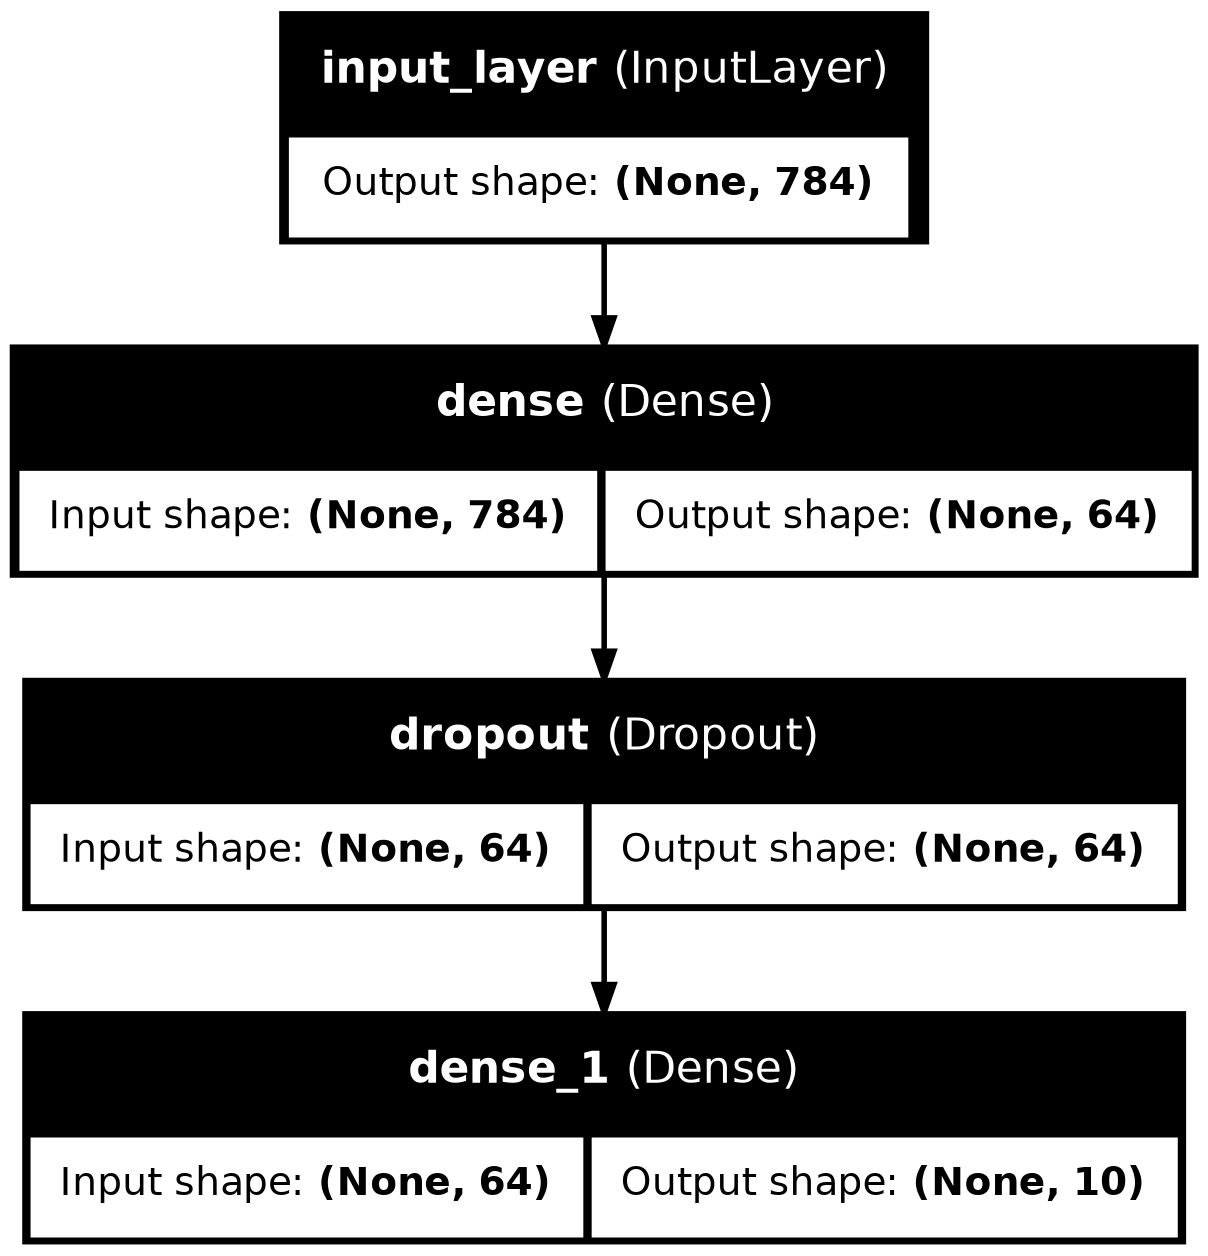

In [4]:
keras.utils.plot_model(functional_classifier, show_shapes=True, show_layer_names=True)

**🧠 Your turn:** Compare this `summary()` to `digit_classifier`'s from
Part 1. Same layers, same shapes — what's actually different between
the two versions?

_Write your answer here:_ `Comparing the two summaries, the layers, output shapes, and param counts are all identical — same architecture, same computation. The only real difference is how the model was defined: Sequential builds it from a flat list of layers, while the Functional API builds it by explicitly calling each layer on a tensor and passing the result to the next, then wrapping it with keras.Model`

## Step 2: One function you'll reuse for the rest of this notebook

Same principle as before: write it once, reuse it for every model
below.

In [5]:
def train_and_evaluate(
    model: keras.Model,
    x: Any,
    y: Any,
    epochs: int = 30,
    batch_size: int = 128,
) -> Dict[str, Any]:
    # Compiles-agnostic: assumes `model` is already compiled.
    # Trains with a 10% validation split and early stopping, then
    # reports how it did. Reused for every model in this notebook.
    #
    # x, y: training inputs and labels. x can be a single array, or a
    # list of arrays for models with more than one input.
    early_stopping = keras.callbacks.EarlyStopping(
        monitor="val_accuracy", patience=3, restore_best_weights=True
    )

    # HINT: call model.fit(...) with x, y, validation_split=0.1, epochs,
    # batch_size, callbacks=[early_stopping], verbose=0 -- store the result
    history = model.fit(x, y,
                        validation_split=0.1,
                        epochs=epochs,
                        batch_size=batch_size,
                        callbacks=[early_stopping],
                        verbose=0
                        )

    return {
        "history": history.history,
        "final_train_accuracy": history.history["accuracy"][-1],
        "final_val_accuracy": history.history["val_accuracy"][-1],
        "epochs_run": len(history.history["loss"]),
    }

In [11]:
functional_classifier.compile(optimizer="adam", loss="sparse_categorical_crossentropy", metrics=["accuracy"])
functional_results = train_and_evaluate(functional_classifier, X_train, y_train)
print(f"Final validation accuracy: {functional_results['final_val_accuracy']:.4f}")

Final validation accuracy: 0.9783


## Step 3: A real multi-input problem — image + text

Here's a genuine reason to want two separate inputs. Picture a bank's
check-processing pipeline: each check has a handwritten digit (the
image) for the amount, *and* a separate typed field where the amount
was also written out in words — a real cross-checking feature actual
check-scanning systems use. The catch: that typed field gets OCR'd
automatically, and OCR sometimes misreads it.

Below, we simulate exactly that: a short text "hint" that agrees with
the true digit most of the time, but is deliberately wrong some of
the time — just like a noisy OCR read would be. (The simulation code
is given below — it's not the point of this step. What matters is
what comes next: building a model that actually takes both inputs.)

`Sequential` can't take two independent inputs like this. The
Functional API can: one `Input` for the image, one `Input` for the
text token, each with its own layers, merged with `Concatenate`
before the final prediction.

📖 [Embedding layer docs](https://www.tensorflow.org/api_docs/python/tf/keras/layers/Embedding) · [Multi-input/output models (Functional API guide)](https://www.tensorflow.org/guide/keras/functional_api#models_with_multiple_inputs_and_outputs) · [Concatenate layer docs](https://www.tensorflow.org/api_docs/python/tf/keras/layers/Concatenate)

In [6]:
DIGIT_WORDS = ["zero", "one", "two", "three", "four", "five", "six", "seven", "eight", "nine"]
OCR_ERROR_RATE = 0.2  # how often the typed hint disagrees with the true digit

def make_noisy_text_hints(true_labels: np.ndarray, error_rate: float) -> np.ndarray:
    # Simulates an OCR'd text field: returns one word-index per example,
    # matching the true label most of the time, but wrong `error_rate`
    # fraction of the time (a random *different* digit). Not the point
    # of this notebook -- just setup so Step 3 has two real inputs to work with.
    rng = np.random.default_rng(RANDOM_SEED)
    is_wrong = rng.random(len(true_labels)) < error_rate
    random_digit = rng.integers(0, 10, size=len(true_labels))
    return np.where(is_wrong, random_digit, true_labels)

train_text_hints = make_noisy_text_hints(y_train, OCR_ERROR_RATE)
test_text_hints = make_noisy_text_hints(y_test, OCR_ERROR_RATE)

print(f"Example: true digit = {y_train[0]}, typed hint = '{DIGIT_WORDS[train_text_hints[0]]}'")
print(f"Hint agrees with true label {np.mean(train_text_hints == y_train):.1%} of the time")

Example: true digit = 5, typed hint = 'five'
Hint agrees with true label 81.9% of the time


In [7]:
image_input = keras.Input(shape=(784,), name="image")
text_input = keras.Input(shape=(1,), name="text_hint")

image_branch = layers.Dense(64, activation="relu")(image_input)

text_branch = layers.Embedding(input_dim=1000, output_dim=8)(text_input)  # HINT: how many possible words are there?
text_branch = layers.Flatten()(text_branch)

combined = layers.Concatenate()([image_branch, text_branch])  # HINT: the other branch
outputs = layers.Dense(10, activation="softmax")(combined)

fusion_model = keras.Model(inputs=[image_input, text_input], outputs=outputs)
fusion_model.summary()

Model: "functional_1"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ text_hint           │ (None, 1)         │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ image (InputLayer)  │ (None, 784)       │          0 │ -                 │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ embedding           │ (None, 1, 8)      │      8,000 │ text_hint[0][0]   │
│ (Embedding)         │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_2 (Dense)     │ (None, 64)        │     50,240 │ image[0][0]       │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ flatten (Flatten)   │ (None, 8)         │          0 │ embedding[0][0]   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ concatenate         │ (None, 72)        │          0 │ dense_2[0][0],    │
│ (Concatenate)       │                   │            │ flatten[0][0]     │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_3 (Dense)     │ (None, 10)        │        730 │ concatenate[0][0] │
└─────────────────────┴───────────────────┴────────────┴───────────────────┘

 Total params: 58,970 (230.35 KB)

 Trainable params: 58,970 (230.35 KB)

 Non-trainable params: 0 (0.00 B)

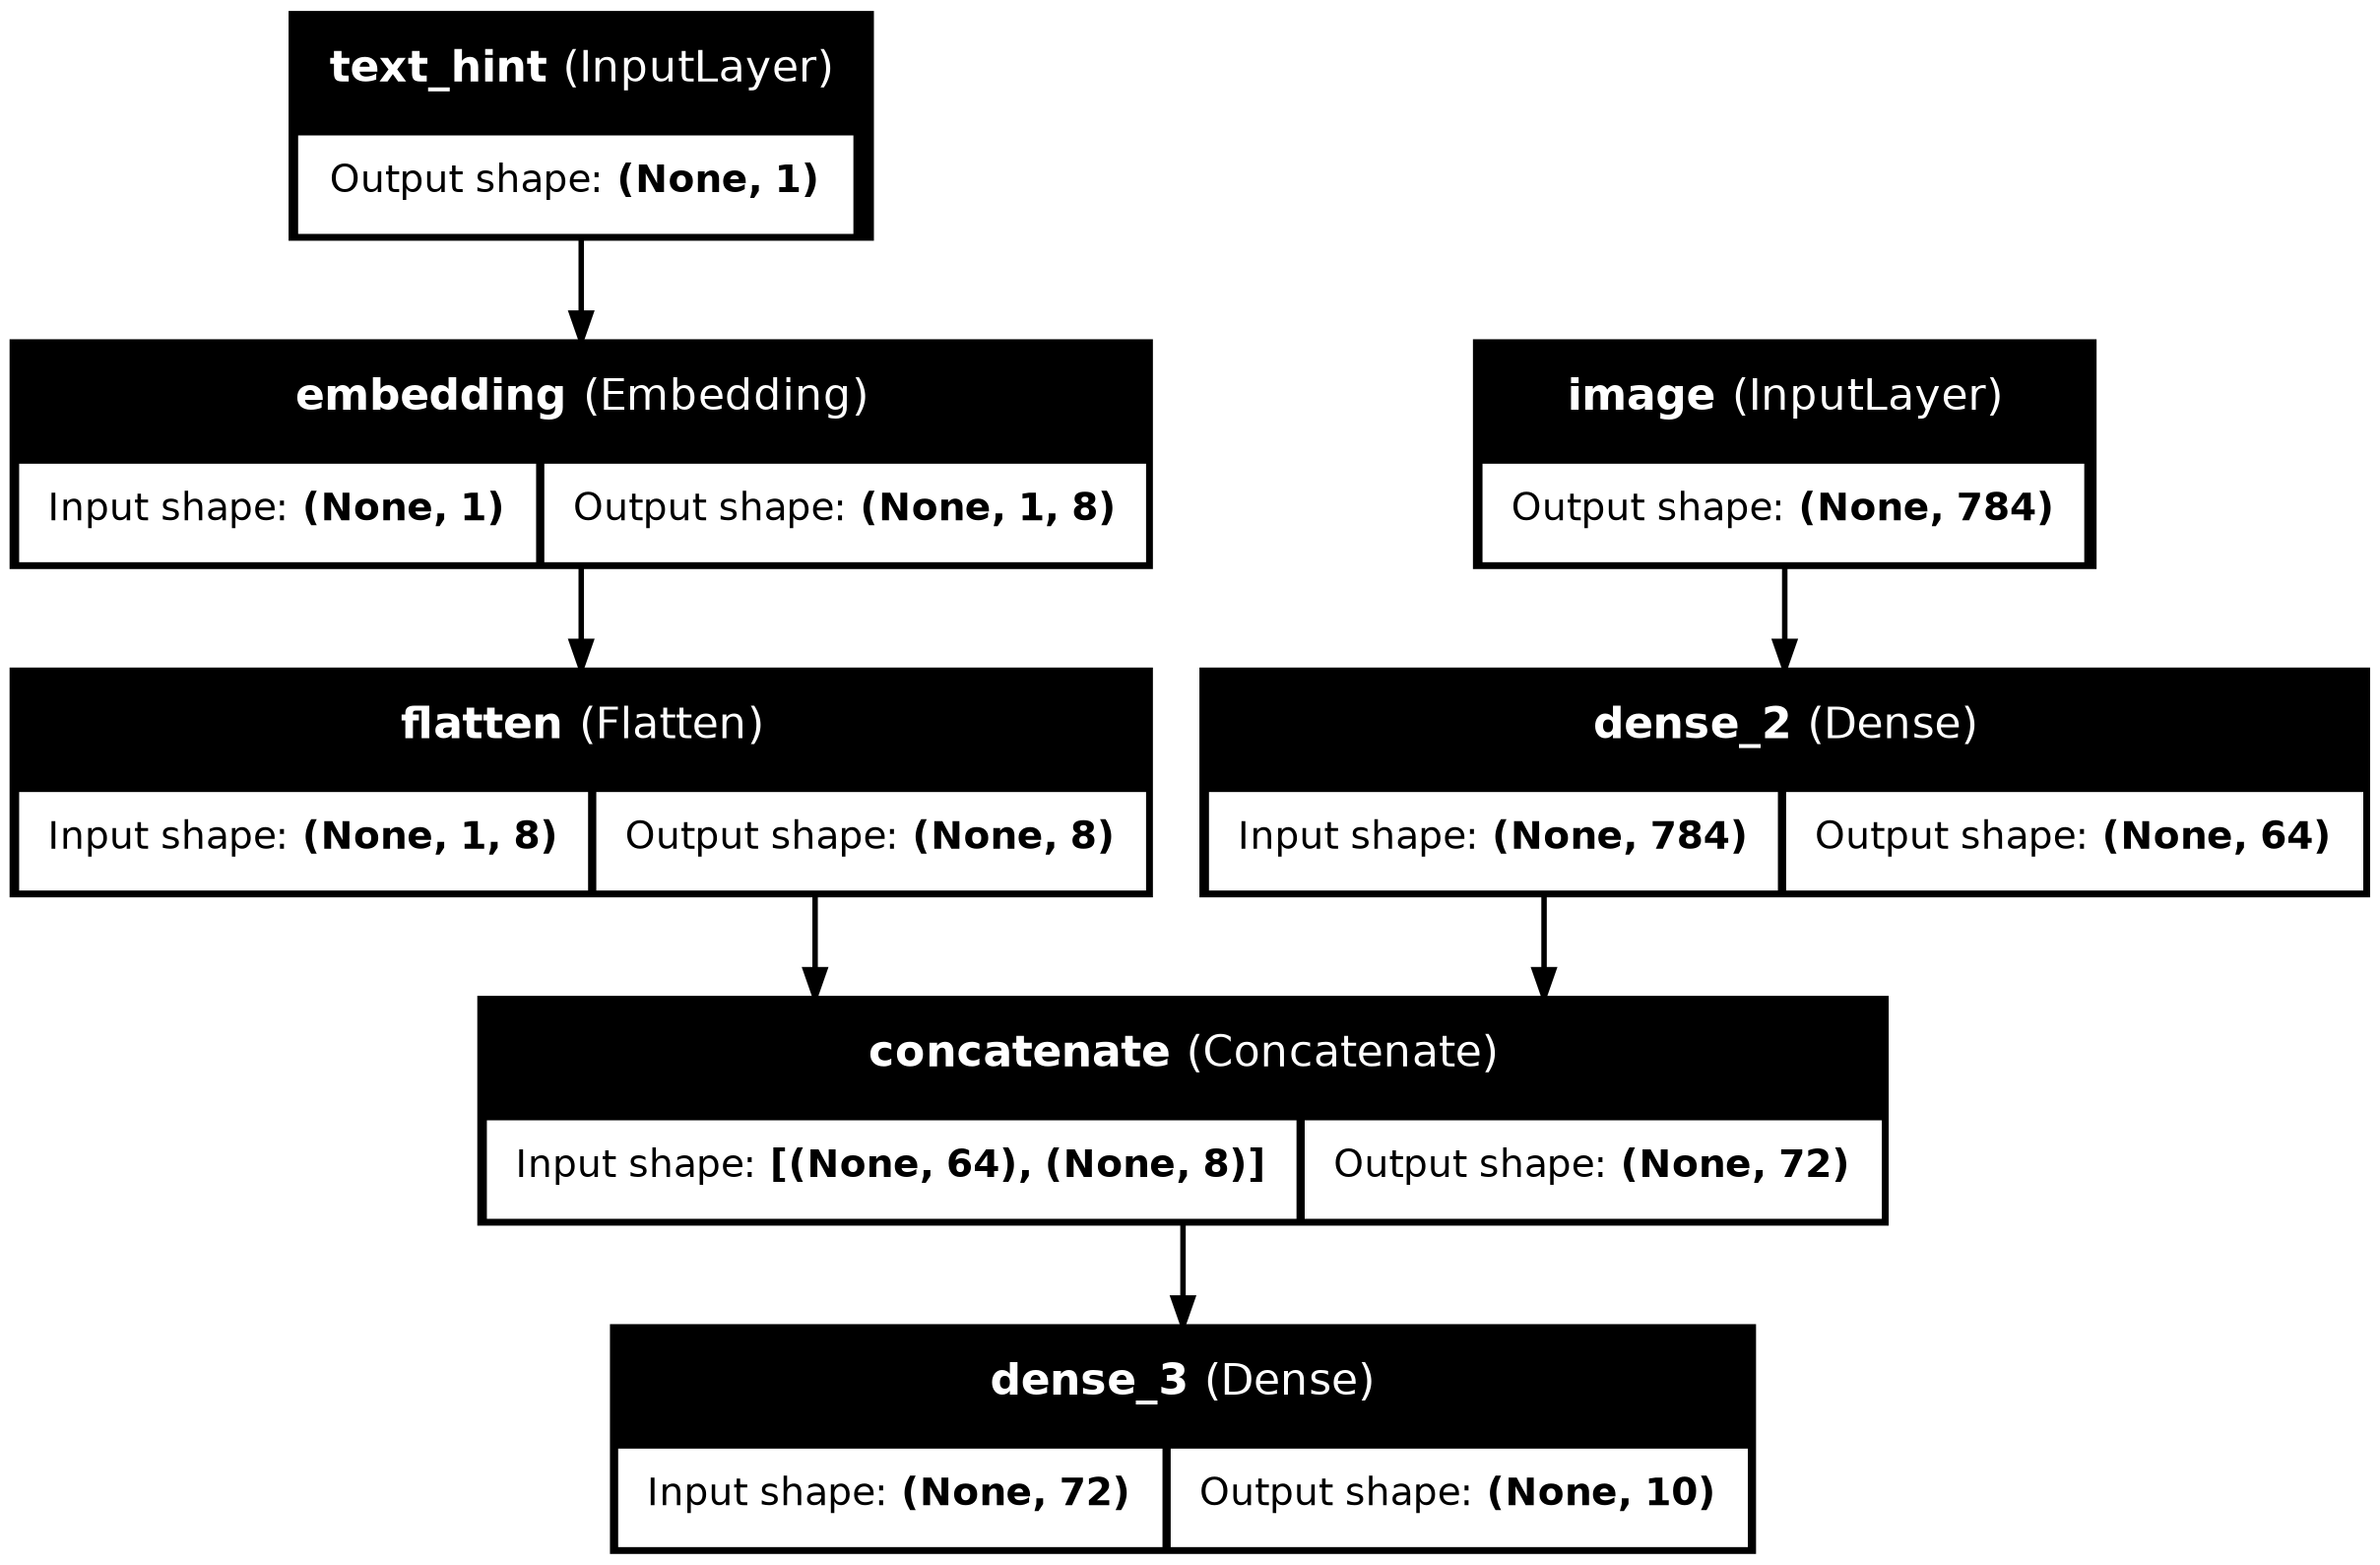

In [8]:
# A text summary lists layers top to bottom, but doesn't show branching.
# For a multi-input model, the picture makes the two-branches-merging
# shape obvious in a way the text summary above doesn't.
keras.utils.plot_model(fusion_model, show_shapes=True, show_layer_names=True)

In [9]:
fusion_model.compile(optimizer="adam", loss="sparse_categorical_crossentropy", metrics=["accuracy"])
fusion_results = train_and_evaluate(fusion_model, x=[X_train, train_text_hints], y=y_train)
print(f"Combined (image + text) validation accuracy: {fusion_results['final_val_accuracy']:.4f}")

Combined (image + text) validation accuracy: 0.9853


**🧠 Your turn:** The text hint alone agrees with the true label about
80% of the time (since `OCR_ERROR_RATE = 0.2`), so a model that only
looked at the text could never beat ~80% accuracy. Did combining it
with the image push accuracy above that ceiling? What does that tell
you about combining two imperfect signals versus trusting either one
alone?

_Write your answer here:_ `I think combining two imperfect can outperform either one alone because their errors do not fully overlap. so one signal's mistakes can be covered by other being right on certain example. This is a similar intuition with ensemble models where individual model weak predictor can produce a stronger or better prediction together`

## Step 4: Branching and merging, more generally

Multiple inputs is one use of the Functional API's flexibility, but
the bigger idea is that a model is really just a **graph of layers**
— data can split into parallel branches and merge back together, even
with a single input. Below, the same image feeds two separate `Dense`
branches of different sizes, and their outputs are concatenated
before the final layer.

📖 [Manipulating complex graph topologies (Functional API guide)](https://www.tensorflow.org/guide/keras/functional_api#manipulate_complex_graph_topologies)

In [11]:
image_input = keras.Input(shape=(784,))

wide_branch = layers.Dense(128, activation="relu")(image_input)
narrow_branch = layers.Dense(16, activation="relu")(image_input)  # HINT: same input as the branch above

merged = layers.Concatenate()([wide_branch, narrow_branch])  # HINT: the other branch
outputs = layers.Dense(10, activation="softmax")(merged)

branching_model = keras.Model(inputs=image_input, outputs=outputs)
branching_model.summary()

Model: "functional_2"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer_1       │ (None, 784)       │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_4 (Dense)     │ (None, 128)       │    100,480 │ input_layer_1[0]… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_5 (Dense)     │ (None, 16)        │     12,560 │ input_layer_1[0]… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ concatenate_1       │ (None, 144)       │          0 │ dense_4[0][0],    │
│ (Concatenate)       │                   │            │ dense_5[0][0]     │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_6 (Dense)     │ (None, 10)        │      1,450 │ concatenate_1[0]… │
└─────────────────────┴───────────────────┴────────────┴───────────────────┘

 Total params: 114,490 (447.23 KB)

 Trainable params: 114,490 (447.23 KB)

 Non-trainable params: 0 (0.00 B)

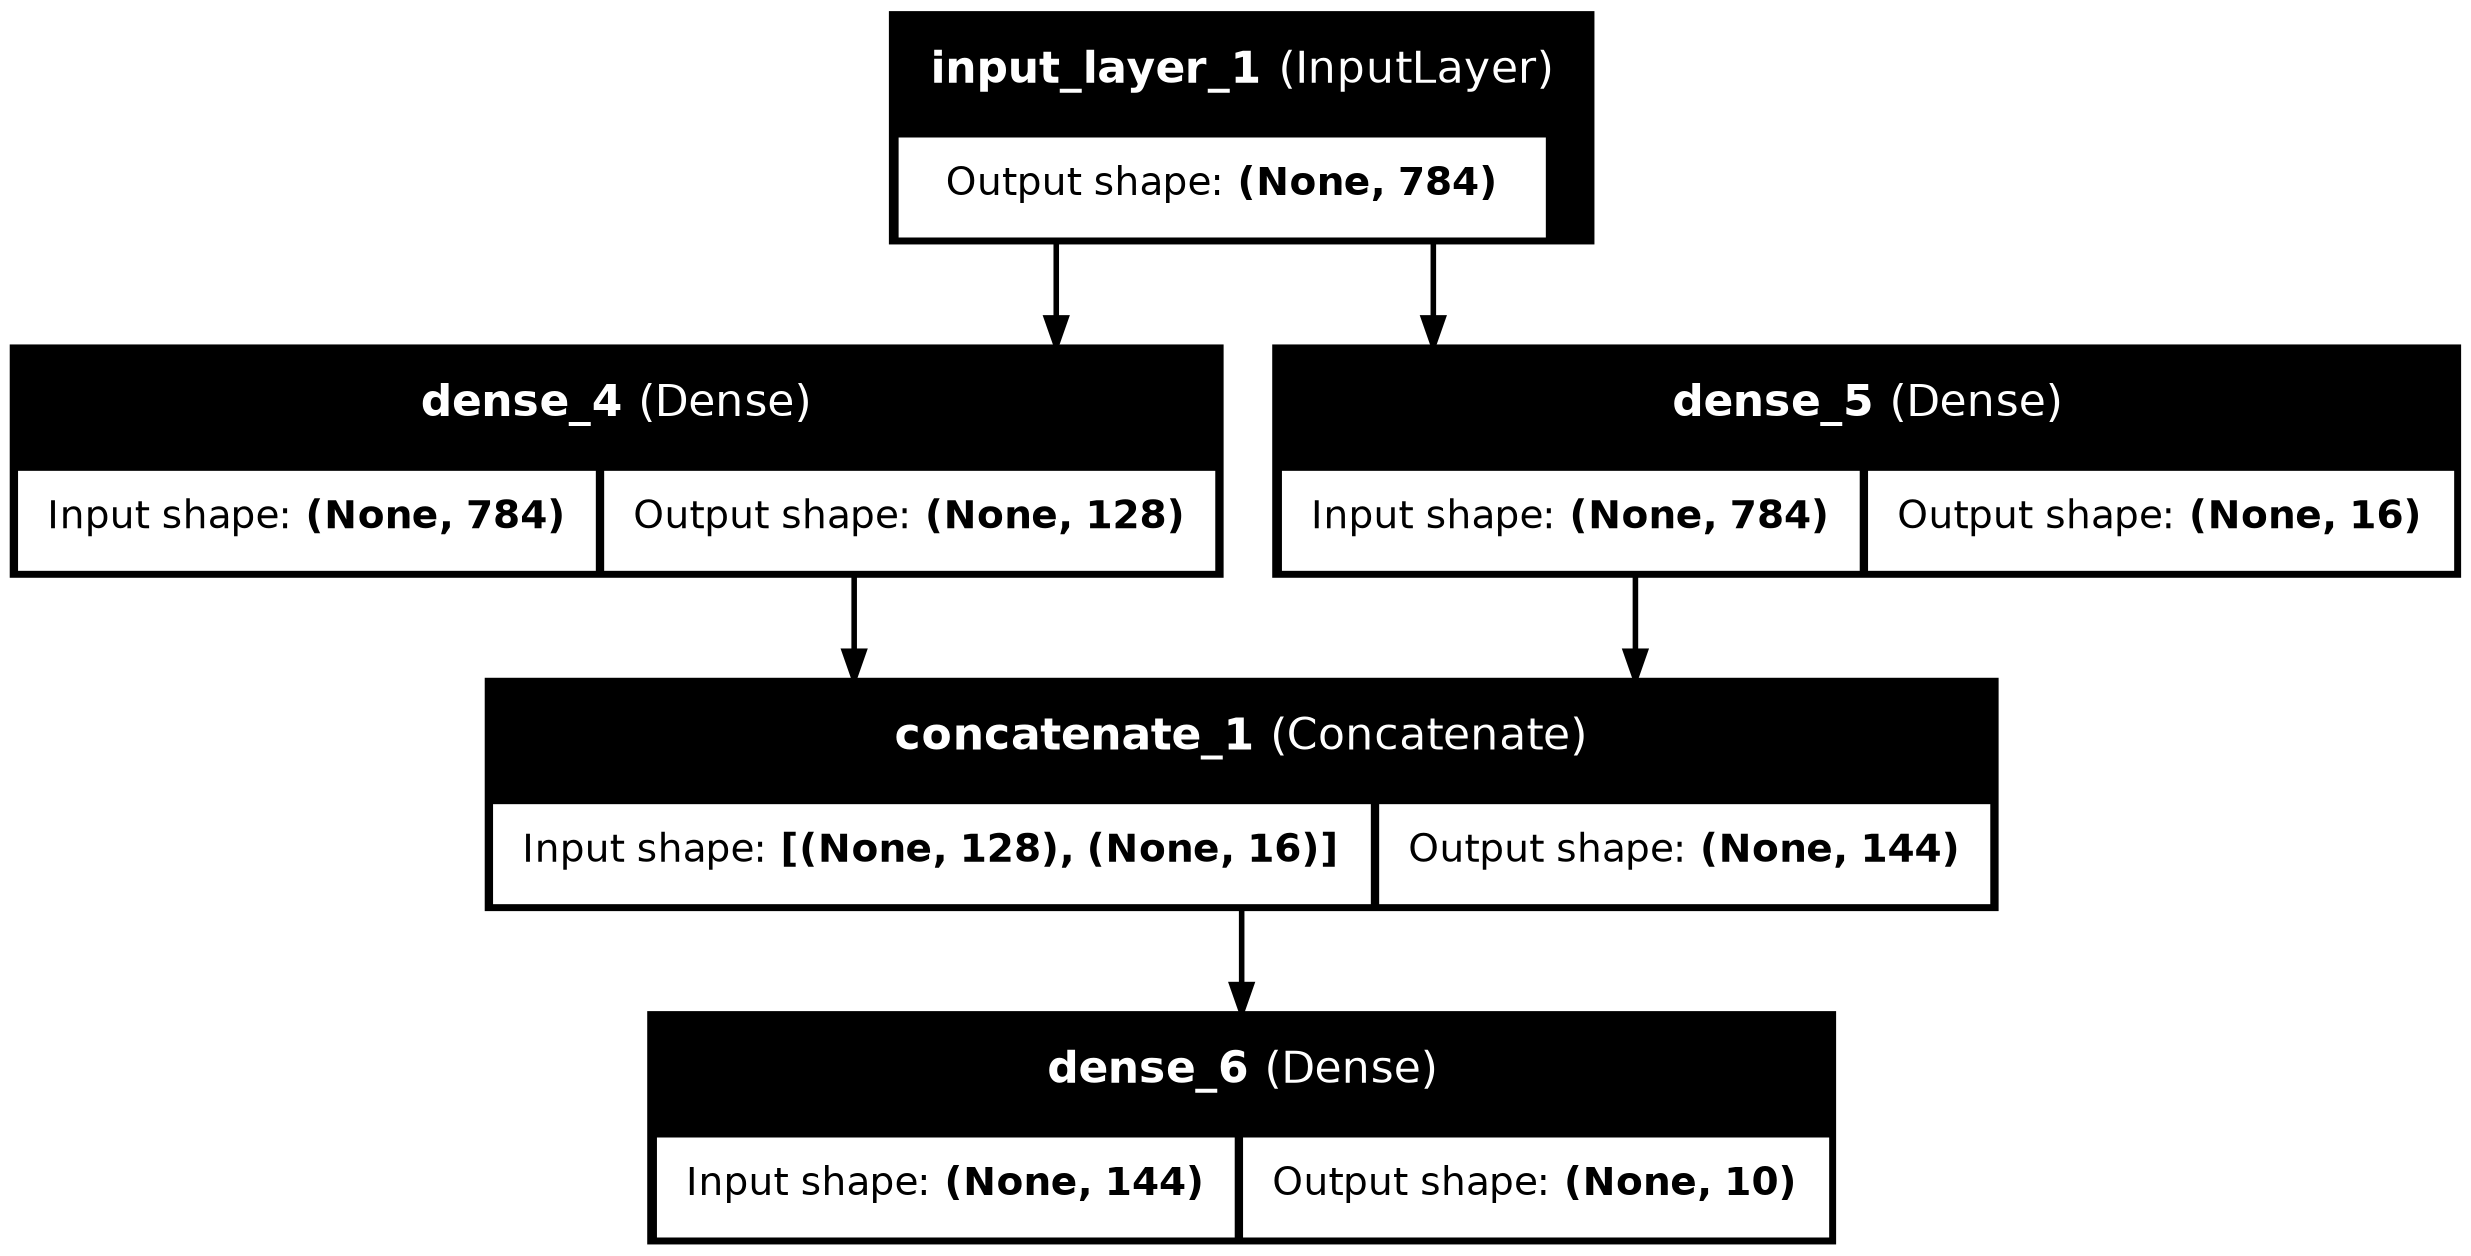

In [12]:
keras.utils.plot_model(branching_model, show_shapes=True, show_layer_names=True)

In [13]:
branching_model.compile(optimizer="adam", loss="sparse_categorical_crossentropy", metrics=["accuracy"])
branching_results = train_and_evaluate(branching_model, X_train, y_train)
print(f"Final validation accuracy: {branching_results['final_val_accuracy']:.4f}")

Final validation accuracy: 0.9770


**🧠 Your turn:** Could you build this exact branching model with
Sequential? Why or why not?

_Write your answer here:_ `No, Sequential can only represent a single straight-line stack of layers, one input to one output. This model has two separate inputs that each go through their own branch of layers before being merged with Concatenate, which requires explicitly wiring multiple tensors together — something Sequential can not express`

## Wrap-up

**Final question:** across this notebook you've now built the same
basic classifier three different ways — the plain Functional
equivalent of Part 1's model, a two-input version, and a branching
version. What's the one thing that stayed identical in every version,
and what changed?

_Write your answer here:_ `Across all three versions, the training and evaluation mechanics stayed completely identical — the same train_and_evaluate function, the same .compile() call, the same .fit() with early stopping, applied without any changes regardless of how the model was structured. 

What changed each time was purely the shape of the computation graph — how tensors were wired together to build the model: a single straight-line stack in the first version, two separate inputs merging after independent branches in the second, and a branching structure with a fork-then-merge in the third. That is the core idea of the Functional API: it separates how you define a model's architecture from how you train it — Keras does not care whether the graph is a straight line or has branches and multiple inputs, .fit() and .compile() work the same either way`

`

## Going further

| Idea | What it roughly controls |
|---|---|
| `Conv2D` + `MaxPooling2D` | Convolutional layers — look at local patterns instead of a flat vector; usually the biggest jump on image data |
| Model subclassing | A third way to build models, writing the forward pass as regular Python code — more flexible than Functional, more work |
| Shared layers | Reusing the *same* layer object in two places in the graph, so it learns one shared representation |
| `model.save()` / `load_model()` | Saving a trained model to disk and reloading it later |

📖 [Convolutional layers (Keras image classification tutorial)](https://www.tensorflow.org/tutorials/images/cnn)